## 1.1 Tasks

 PyTorch Version : 2.6.0+cpu


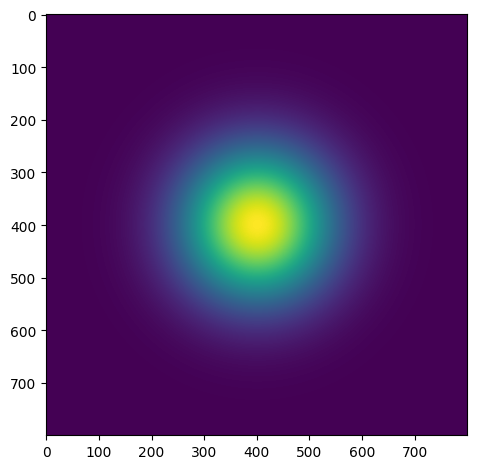

In [5]:
import torch
import numpy as np

print (" PyTorch Version :", torch . __version__ )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# grid for computing image , subdivide the space
X , Y = np.mgrid [ -4.0:4:0.01 , -4.0:4:0.01]

# load into PyTorch tensors
x = torch.Tensor ( X )
y = torch.Tensor ( Y )

# Compute Gaussian
z = torch.exp (-( x **2+ y **2) /2.0)

# plot
import matplotlib . pyplot as plt
plt.imshow( z.cpu().numpy())# Updated !
plt.tight_layout ()
plt.show ()

## 1.2 AI tasks

### use numpy

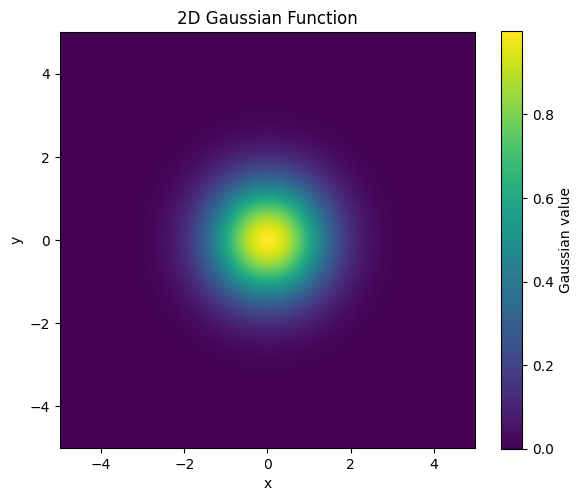

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# gaussian function
def gaussian(x, y):
    return np.exp(-(x ** 2 + y ** 2) / 2.0)

# Create a grid of points from -5 to 5 in both x and y directions with 200 points in each direction
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)

# Convert the 1D arrays into 2D grids for x and y
x_grid, y_grid = np.meshgrid(x, y)

# runs the gaussian function on the grid
z = gaussian(x_grid, y_grid)

# figure 6 inches wide and 5 inches tall
plt.figure(figsize=(6, 5))

# Display the Gaussian function as an image with a color map
plt.imshow(
    z,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="viridis",
)
plt.colorbar(label="Gaussian value")
plt.title("2D Gaussian Function")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


### convert to pytorch

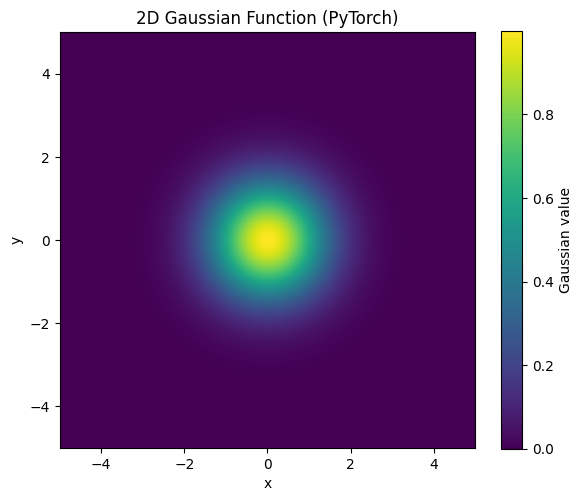

In [ ]:
import torch
import matplotlib.pyplot as plt

# Define the Gaussian function using PyTorch
def gaussian(x, y):
    return torch.exp(-(x ** 2 + y ** 2) / 2.0)


x = torch.linspace(-5, 5, 200)
y = torch.linspace(-5, 5, 200)
x_grid, y_grid = torch.meshgrid(x, y, indexing="xy")
z = gaussian(x_grid, y_grid)

plt.figure(figsize=(6, 5))
plt.imshow(
    z,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="viridis",
)
plt.colorbar(label="Gaussian value")
plt.title("2D Gaussian Function (PyTorch)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


### 2d sine function

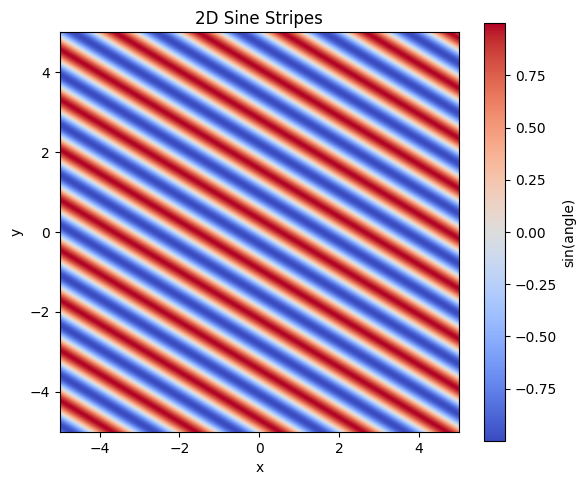

In [ ]:
import torch
import matplotlib.pyplot as plt

# change from Gaussian to sine function
def sine_2d(x, y):
    angle = 3.0 * x + 5.0 * y
    return torch.sin(angle)


x = torch.linspace(-5, 5, 400)
y = torch.linspace(-5, 5, 400)
x_grid, y_grid = torch.meshgrid(x, y, indexing="xy")
z = sine_2d(x_grid, y_grid)

plt.figure(figsize=(6, 5))
plt.imshow(
    z,
    extent=[-5, 5, -5, 5],
    origin="lower",
    cmap="coolwarm",
)
plt.colorbar(label="sin(angle)")
plt.title("2D Sine Stripes")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


#### Prompt 1
> Generate a Python script to plot a 2D Gaussian function using NumPy and Matplotlib.

#### Additional prompts
> Use the Gaussian function `exp(-(x**2 + y**2) / 2.0)`.

> Make the visualisation simpler.

#### Prompt 2
> Convert this script to PyTorch and use PyTorch tensors instead of NumPy. Put it in a new cell.

#### Prompt 3
> Generate a 2D sine function whose angle depends on both the x and y coordinates using PyTorch tensors. Show a plot with stripes and put it in a new cell.

#### Simple explanation
The first prompt generated a basic 2D Gaussian plot using NumPy and Matplotlib. Additional prompts were needed because the first result did not use the exact Gaussian formula from the previous section and the visualisation was more complicated than necessary.

The second prompt converted the NumPy code into PyTorch so that tensors were used for the calculations.

The third prompt generated a 2D sine function using `sin(3x + 5y)`. Since the angle depends on both `x` and `y`, the output forms diagonal stripes.

## 1.3 Demonstration

### sine function and gabor filter

 PyTorch Version : 2.6.0+cpu


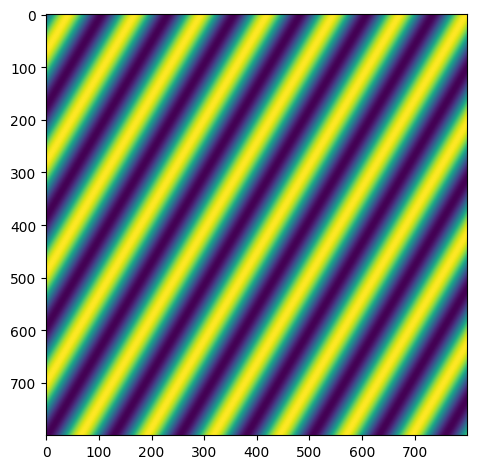

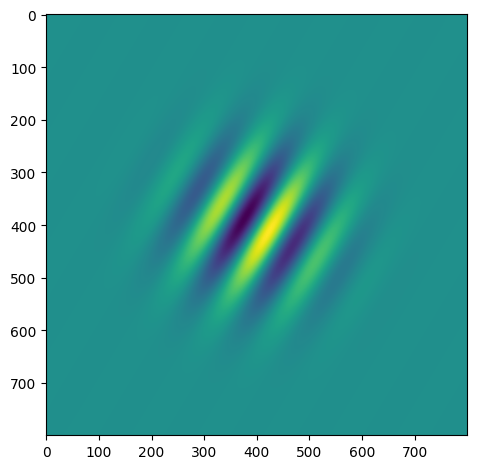

In [14]:
import torch
import numpy as np

print (" PyTorch Version :", torch . __version__ )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# grid for computing image , subdivide the space
X , Y = np.mgrid [ -4.0:4:0.01 , -4.0:4:0.01]

# load into PyTorch tensors
x = torch.Tensor ( X )
y = torch.Tensor ( Y )

# Compute sine function
z_sine = torch.sin (3.0 * x + 5.0 * y)

#compute Gaussian
z_gaussian = torch.exp (-( x **2+ y **2) /2.0)

# gabor filter
Z = z_sine * z_gaussian

# plot
import matplotlib . pyplot as plt
plt.imshow( z_sine.cpu().numpy())# Updated !
plt.tight_layout ()
plt.show ()

# plot gabor filter
plt.imshow( Z.cpu().numpy())# Updated !
plt.tight_layout ()
plt.show ()

The Gaussian function creates a bright area in the centre that gradually becomes darker toward the edges.

The sine function creates repeating diagonal stripes because its angle depends on both `x` and `y`:

$$
\sin(3x + 5y)
$$

The Gaussian and sine functions are then multiplied together:

$$
Z = \text{sine} \times \text{Gaussian}
$$

The result is a Gabor filter. The sine function provides the striped pattern, while the Gaussian function reduces the stripe intensity away from the centre. Therefore, the final image has strong stripes near the centre that gradually fade toward the edges.

## 2.1 Tasks

### mandelbrot set

C:\Users\kevin\AppData\Local\Temp\ipykernel_19300\3203299575.py:51: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np.uint8(np.clip(a, 0, 255))


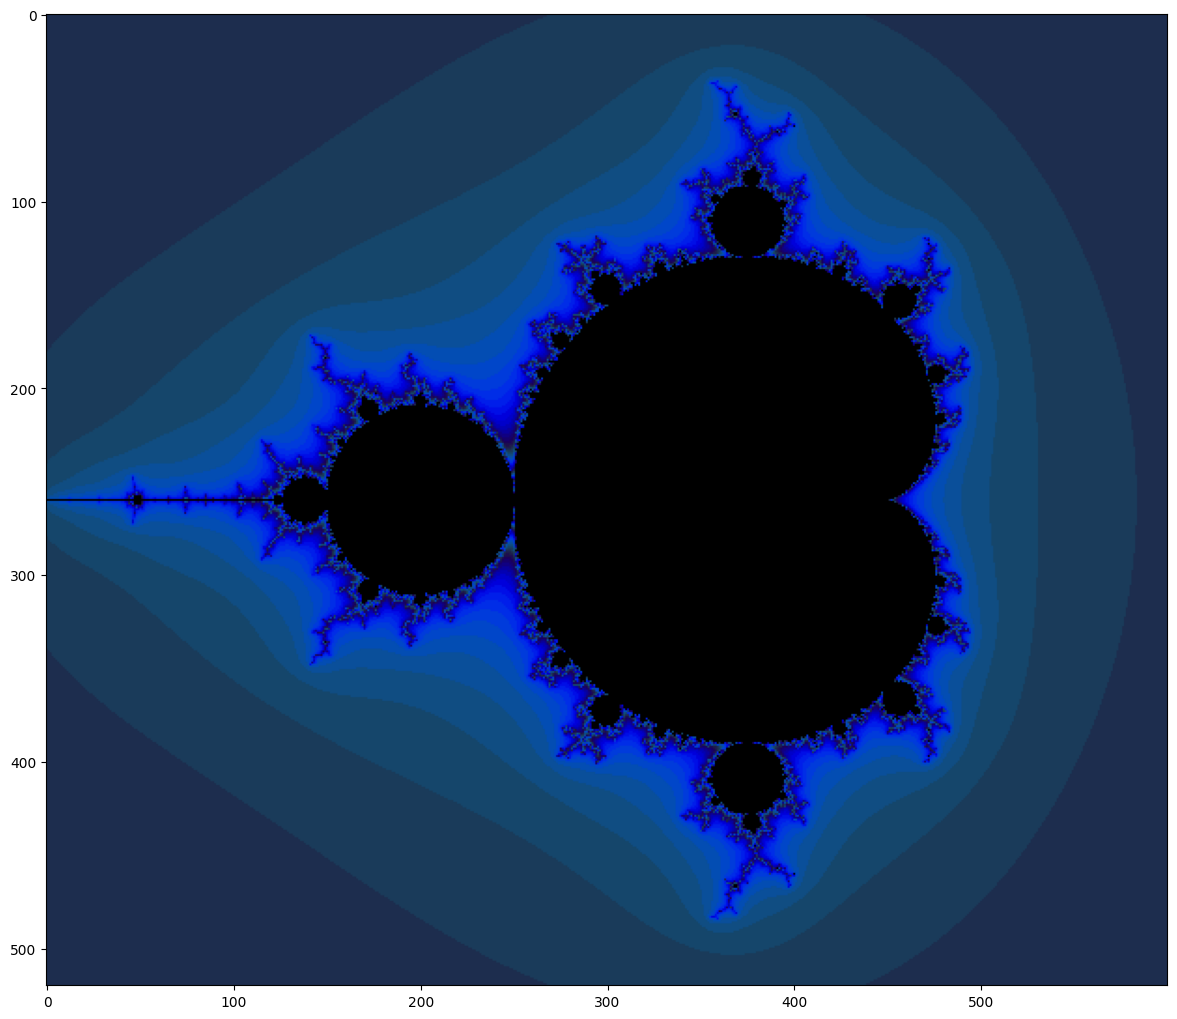

In [ ]:
import torch
import numpy as np

# Device configuration
device = torch.device ('cuda' if torch.cuda.is_available() else 'cpu')

# Use NumPy to create a 2D array of complex numbers on [ -2 ,2]x[ -2 ,2]
Y , X = np . mgrid [ -1.3:1.3:0.005 , -2:1:0.005]

# load into PyTorch tensors
x = torch . Tensor ( X )
y = torch . Tensor ( Y )

# combine so now we have a 2D array of complex numbers, C
z = torch . complex (x , y ) # important !

# value that will be used to compute the Mandelbrot set
zs = z . clone () # Updated !
ns = torch . zeros_like ( z )

# transfer to the GPU device
z = z . to ( device )
zs = zs . to ( device )
ns = ns . to ( device )

# Mandelbrot Set
for i in range (200) :
  # Compute the new values of z: z^2 + x in parallel
  zs_ = zs * zs + z
  # Have we diverged with this new value ?
  not_diverged = torch .abs ( zs_ ) < 4.0
  # Update variables to compute
  ns += not_diverged # count how long each point has not diverged
  zs = zs_

# plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 10))

# Take the iteration numbers and convert them into colours.
def processFractal(a):
    """Display an array of iteration counts as a
    colorful picture of a fractal."""
    a_cyclic = (6.28 * a / 20.0).reshape(list(a.shape) + [1])
    img = np.concatenate(
        [
            10 + 20 * np.cos(a_cyclic),
            30 + 50 * np.sin(a_cyclic),
            155 - 80 * np.cos(a_cyclic),
        ],
        2,
    )
    img[a == a.max()] = 0 # Points that survive the maximum number of iterations are considered part of the Mandelbrot set. black
    a = img
    a = np.uint8(np.clip(a, 0, 255))
    return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

## 2.2 AI Tasks

CUDA is not available; running on CPU instead.


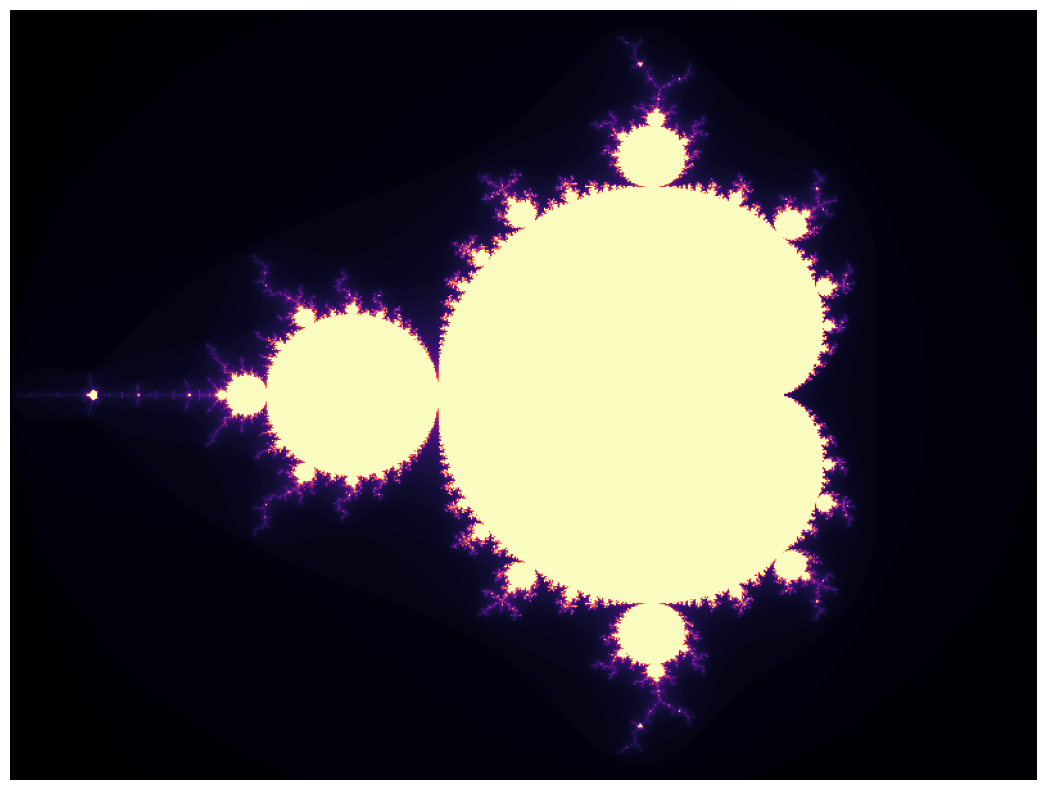

In [ ]:
import torch
import matplotlib.pyplot as plt


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    print("CUDA is not available; running on CPU instead.")

# Set image size and number of iterations
width = 800
height = 600
max_iter = 100

# Create a grid of complex numbers representing the Mandelbrot set
real = torch.linspace(-2.0, 1.0, width, device=device)
imag = torch.linspace(-1.2, 1.2, height, device=device)
c_real, c_imag = torch.meshgrid(real, imag, indexing="xy")

# start with z = 0 for all points in the complex plane
z_real = torch.zeros_like(c_real)
z_imag = torch.zeros_like(c_imag)

# create a tensor to hold the number of iterations for each point
iterations = torch.zeros(c_real.shape, dtype=torch.int32, device=device)

# create a boolean mask to track which points are still active (not escaped)
active = torch.ones(c_real.shape, dtype=torch.bool, device=device)

for i in range(max_iter):

    # Compute the next values of z: z^2 + c in parallel
    z_real_next = z_real ** 2 - z_imag ** 2 + c_real
    z_imag_next = 2 * z_real * z_imag + c_imag

    # If the point is still active, update it. Otherwise keep its old value.
    z_real = torch.where(active, z_real_next, z_real)
    z_imag = torch.where(active, z_imag_next, z_imag)


    escaped = (z_real ** 2 + z_imag ** 2 > 4.0) & active

    # store the iteration count for points that have escaped and mark them as inactive
    iterations[escaped] = i

    # remove points that have escaped from the active mask
    active = active & ~escaped

# Points that haven't escaped after max_iter iterations are considered part of the Mandelbrot set
iterations[active] = max_iter

plt.figure(figsize=(16, 10))
plt.imshow(iterations.cpu(), cmap="magma")
plt.axis("off")
plt.show()


#### Prompt 1
> Generate a Mandelbrot set using PyTorch tensors that runs on the GPU and visualise it using Matplotlib.

#### Additional prompt
> Make the plot simpler.

#### Explanation
The AI model successfully generated a Mandelbrot set using PyTorch tensors and selected the GPU when CUDA was available. It also moved the final result back to the CPU before plotting with Matplotlib.

An additional prompt was needed because the original visualisation was more complicated than necessary. The plot was simplified to use only `imshow()` with the axes hidden.

I also manually changed the figure size from `(6, 4)` to `(16, 10)` so that the Mandelbrot set appeared larger and easier to inspect.

The code can still run when a GPU is unavailable because it falls back to the CPU. Overall, the AI-generated code worked well, but a small visualisation adjustment was needed.

## 2.3 Demonstration

### zoomed version

C:\Users\kevin\AppData\Local\Temp\ipykernel_22392\1721943467.py:51: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np.uint8(np.clip(a, 0, 255))


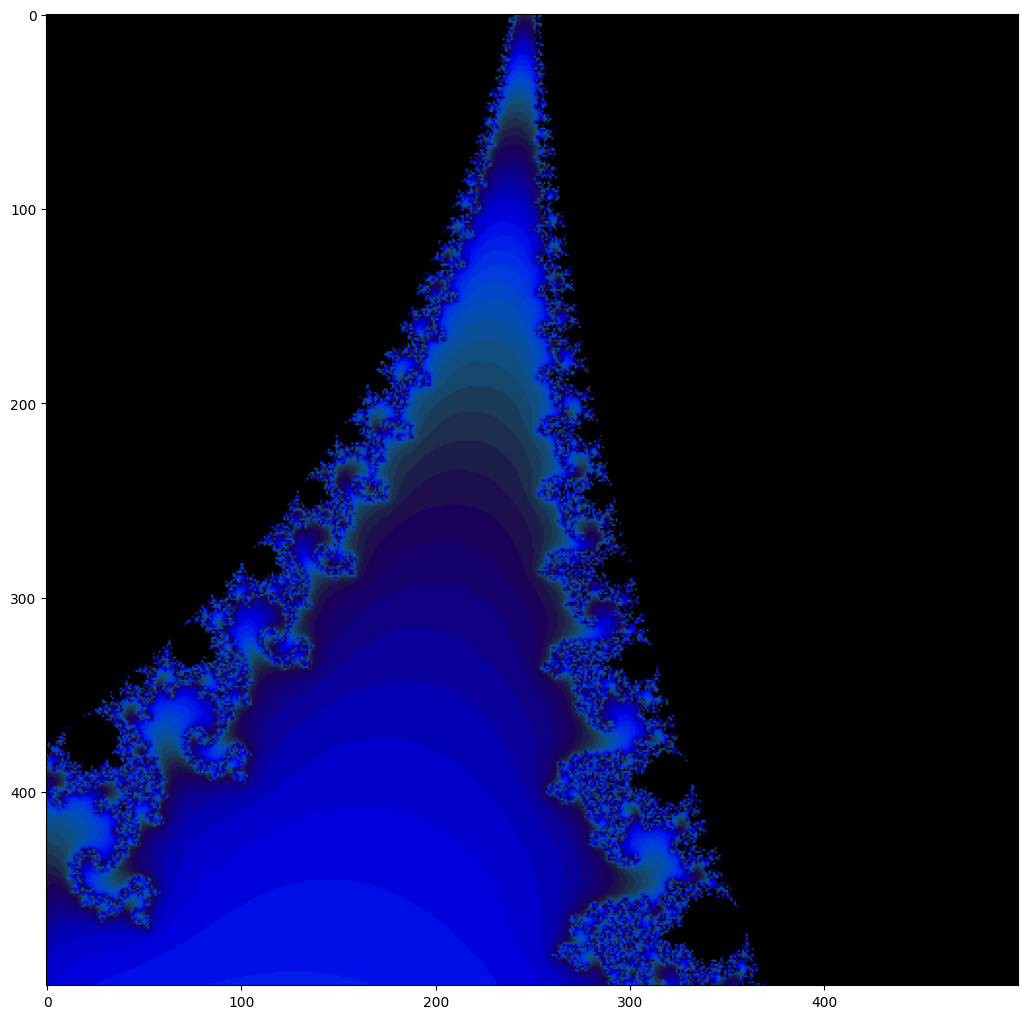

In [ ]:
import torch
import numpy as np

# Device configuration
device = torch.device ('cuda' if torch.cuda.is_available() else 'cpu')

# Use NumPy to create a 2D array of complex numbers on [ -2 ,2]x[ -2 ,2]
Y, X = np.mgrid[0.05:0.25:0.0004, -0.85:-0.65:0.0004] # compute smaller set, zoomed region of the Mandelbrot set

# load into PyTorch tensors
x = torch . Tensor ( X )
y = torch . Tensor ( Y )
z = torch . complex (x , y ) # important !
zs = z . clone () # Updated !
ns = torch . zeros_like ( z )

# transfer to the GPU device
z = z . to ( device )
zs = zs . to ( device )
ns = ns . to ( device )

# Mandelbrot Set
for i in range (300) : # increased iterations for better detail in the zoomed region
  # Compute the new values of z: z^2 + x
  zs_ = zs * zs + z
  # Have we diverged with this new value ?
  not_diverged = torch .abs ( zs_ ) < 4.0
  # Update variables to compute
  ns += not_diverged
  zs = zs_

# plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 10))

def processFractal(a):
    """Display an array of iteration counts as a
    colorful picture of a fractal."""
    a_cyclic = (6.28 * a / 20.0).reshape(list(a.shape) + [1])
    img = np.concatenate(
        [
            10 + 20 * np.cos(a_cyclic),
            30 + 50 * np.sin(a_cyclic),
            155 - 80 * np.cos(a_cyclic),
        ],
        2,
    )
    img[a == a.max()] = 0
    a = img
    a = np.uint8(np.clip(a, 0, 255))
    return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

This zooms into another part of the Mandelbrot set near x = -0.75, y = 0.15, and decreases spacing from 0.005 to 0.0004. This created more pixels and gave a higher-resolution image. I also increased the iterations from 200 to 300 to show more detail around the boundary. The number of iterations means how many times the Mandelbrot formula is repeated for every point, although this made the computation slower.

### julia set

C:\Users\kevin\AppData\Local\Temp\ipykernel_22392\2824673029.py:54: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np.uint8(np.clip(a, 0, 255))


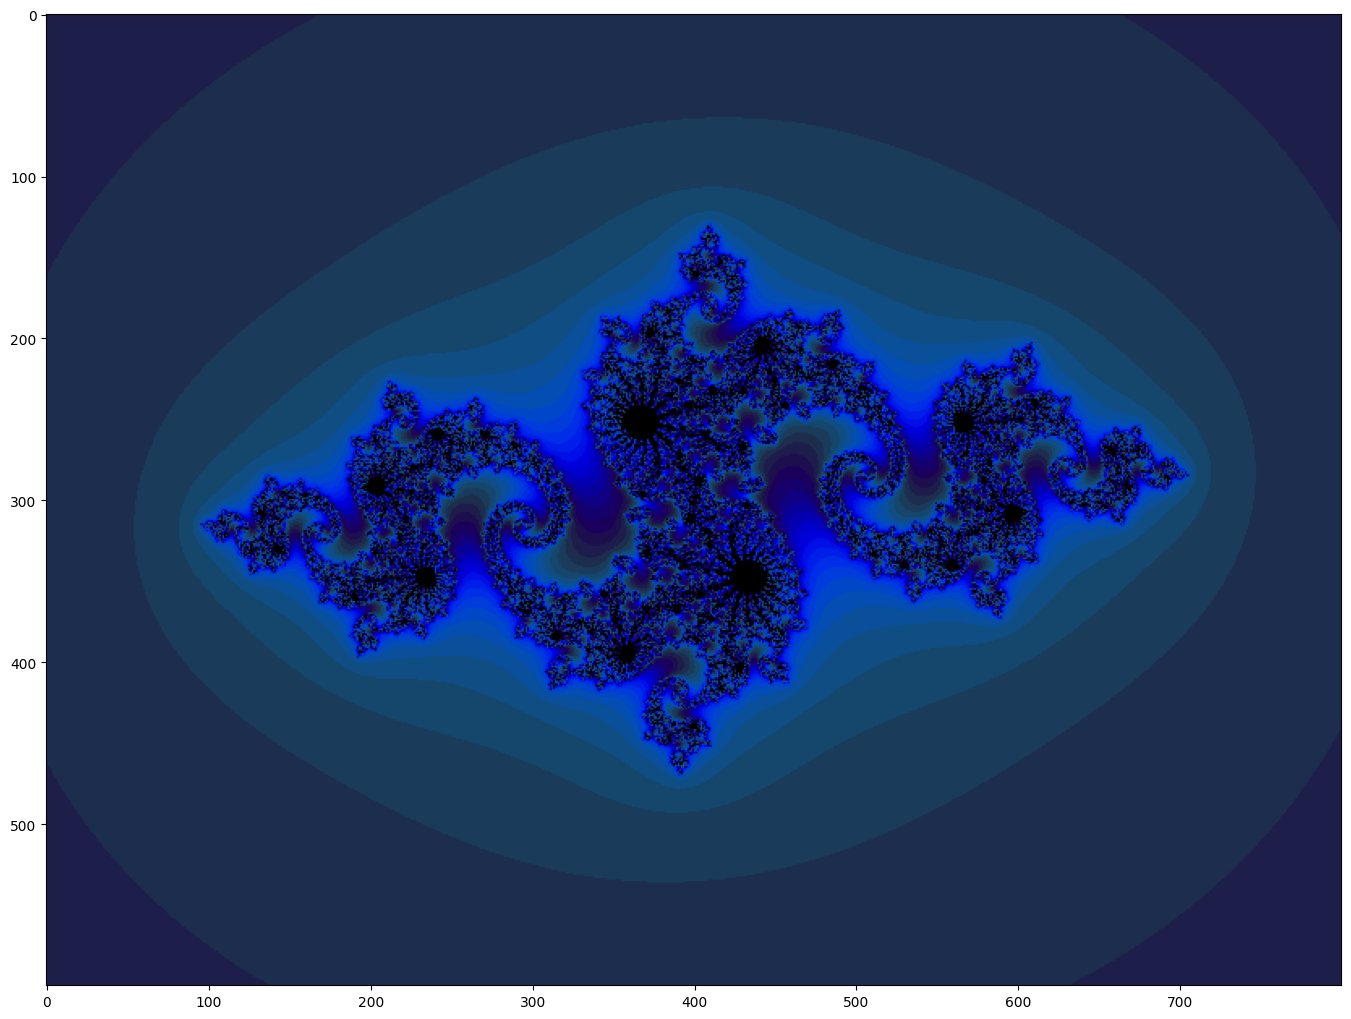

In [ ]:
import torch
import numpy as np

# Device configuration
device = torch.device ('cuda' if torch.cuda.is_available() else 'cpu')

# Use NumPy to create a 2D array of complex numbers on [ -2 ,2]x[ -2 ,2]
Y , X = np . mgrid [ -1.5:1.5:0.005 , -2:2:0.005]

# load into PyTorch tensors
x = torch . Tensor ( X )
y = torch . Tensor ( Y )
z = torch . complex (x , y ) # important !
zs = z . clone () # Updated !
ns = torch . zeros_like ( z )

# transfer to the GPU device
z = z . to ( device )
zs = zs . to ( device )
ns = ns . to ( device )

# c is a complex constant that defines the specific Julia set to be computed.
c = torch.tensor(-0.8 + 0.156j, dtype=z.dtype, device=device)

# Julia Set
for i in range (200) :
  # julia set computation: z = z^2 + c
  zs_ = zs * zs + c
  # Have we diverged with this new value ?
  not_diverged = torch .abs ( zs_ ) < 4.0
  # Update variables to compute
  ns += not_diverged
  zs = zs_

# plot
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 10))

def processFractal(a):
    """Display an array of iteration counts as a
    colorful picture of a fractal."""
    a_cyclic = (6.28 * a / 20.0).reshape(list(a.shape) + [1])
    img = np.concatenate(
        [
            10 + 20 * np.cos(a_cyclic),
            30 + 50 * np.sin(a_cyclic),
            155 - 80 * np.cos(a_cyclic),
        ],
        2,
    )
    img[a == a.max()] = 0
    a = img
    a = np.uint8(np.clip(a, 0, 255))
    return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

To modify the Mandelbrot code into a Julia set, I kept the grid as the starting complex values \(z\), but replaced the varying value \(c\) with one fixed complex constant.

In the Mandelbrot set, each pixel acts as the value of \(c\), and the update rule is:

$$
z_{n+1} = z_n^2 + c
$$

where \(c\) changes for every pixel.

For the Julia set, I used a fixed constant c = torch.tensor(-0.8 + 0.156j, dtype=z.dtype, device=device)


## 3.3 Tasks

## initial koch curve

Using: cpu


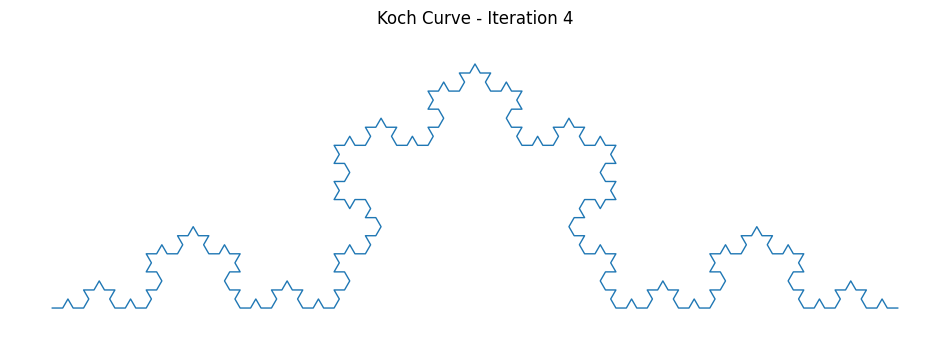

In [ ]:
import torch
import matplotlib.pyplot as plt
import math

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# Starting line: (0, 0) -> (1, 0)
points = torch.tensor([
    [0.0, 0.0],
    [1.0, 0.0]
], device=device)


def koch_step(points):
    new_points = []

    # Go through each line segment
    for i in range(len(points) - 1):

        # Get the start and end points of the segment
        start = points[i]
        end = points[i + 1]

        # Direction of the line
        direction = end - start

        # Points at 1/3 and 2/3
        p1 = start + direction / 3
        p3 = start + 2 * direction / 3

        # Middle third of the line
        middle = direction / 3

        # Rotate the middle third by 60 degrees
        angle = math.pi / 3

        # Create a rotation matrix for 60 degrees
        rotation = torch.tensor([
            [math.cos(angle), -math.sin(angle)],
            [math.sin(angle),  math.cos(angle)]
        ], device=device)

        rotated = rotation @ middle

        # Top point of the triangular bump
        p2 = p1 + rotated

        # Store the new points, matplotlib will connect them in order
        new_points.extend([
            start,
            p1,
            p2,
            p3
        ])

    # Add the final endpoint
    new_points.append(points[-1])

    return torch.stack(new_points)


# Number of iterations
iterations = 4

for i in range(iterations):
    points = koch_step(points)


# Move to CPU so Matplotlib can use the data
points_cpu = points.cpu().numpy()

# Plot the Koch curve
plt.figure(figsize=(12, 4))

plt.plot(
    points_cpu[:, 0], # take the x-coordinates of the points
    points_cpu[:, 1], # take the y-coordinates of the points
    linewidth=1
)

plt.title(f"Koch Curve - Iteration {iterations}")
plt.axis("equal")
plt.axis("off")

plt.show()

## parallel koch curve

Using: cpu


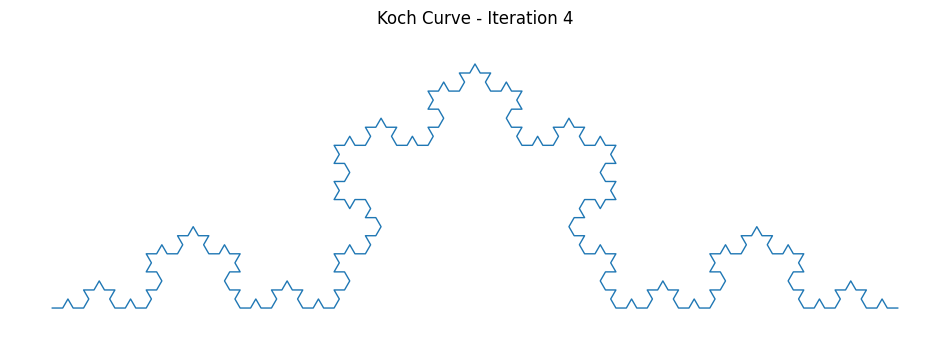

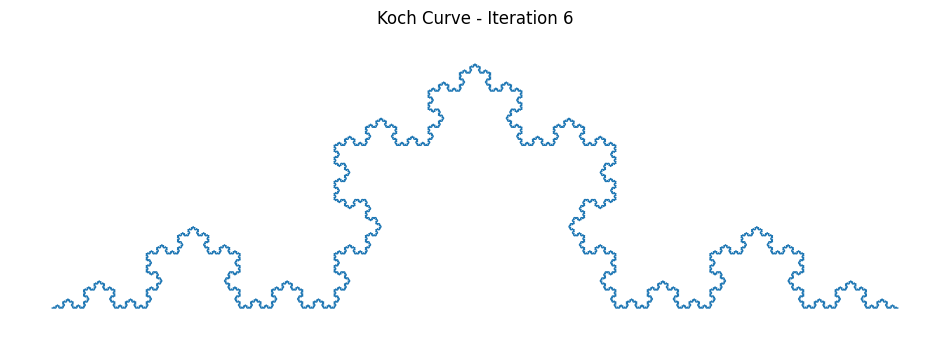

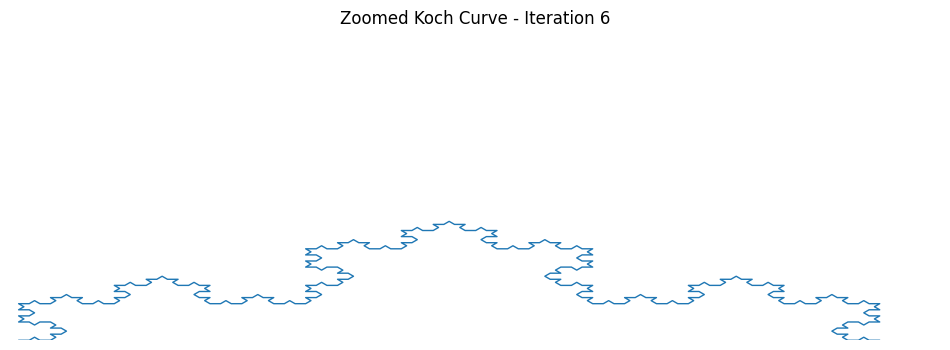

In [ ]:
import torch
import matplotlib.pyplot as plt
import math

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# Starting line
def make_starting_points():
    return torch.tensor([
        [0.0, 0.0],
        [1.0, 0.0]
    ], device=device)


def koch_step(points):

    # All segment starting points
    start = points[:-1]

    # All segment ending points
    end = points[1:]

    # Direction of every segment at once
    direction = end - start

    # Points at 1/3 and 2/3 for every segment
    p1 = start + direction / 3
    p3 = start + 2 * direction / 3

    # Middle third of every segment
    middle = direction / 3

    # Rotate every middle segment by 60 degrees
    angle = math.pi / 3

    # Create a rotation matrix for 60 degrees
    x = middle[:, 0]
    y = middle[:, 1]

    rotated = torch.stack([
        x * math.cos(angle) - y * math.sin(angle),
        x * math.sin(angle) + y * math.cos(angle)
    ], dim=1)

    # Peak of the triangular bump
    p2 = p1 + rotated

    # Put the new points together
    new_points = torch.stack([
        start,
        p1,
        p2,
        p3
    ], dim=1)

    # Reshape to a 2D array of points, flattening the segments into a single list of points
    new_points = new_points.reshape(-1, 2)

    # Add the final endpoint
    new_points = torch.cat([
        new_points,
        points[-1].unsqueeze(0) # Add the last point to the end of the new points
    ], dim=0)

    return new_points


# Number of iterations
points = make_starting_points()

iterations = 4

for i in range(iterations):
    points = koch_step(points)


# Move to CPU for Matplotlib
points_cpu = points.cpu().numpy()

plt.figure(figsize=(12, 4))

plt.plot(
    points_cpu[:, 0],
    points_cpu[:, 1],
    linewidth=1
)

plt.title(f"Koch Curve - Iteration {iterations}")
plt.axis("equal")
plt.axis("off")

plt.show()

# Number of iterations

points = make_starting_points()

iterations = 6

for i in range(iterations):
    points = koch_step(points)


# Move to CPU for Matplotlib
points_cpu = points.cpu().numpy()

plt.figure(figsize=(12, 4))

plt.plot(
    points_cpu[:, 0],
    points_cpu[:, 1],
    linewidth=1
)

plt.title(f"Koch Curve - Iteration {iterations}")
plt.axis("equal")
plt.axis("off")

plt.show()

# zoom in on the Koch curve by changing the figure size and axis limits

plt.figure(figsize=(12, 4))

plt.plot(
    points_cpu[:, 0],
    points_cpu[:, 1],
    linewidth=1
)

plt.xlim(0.11, 0.23)
plt.ylim(0.05, 0.17)

plt.title(f"Zoomed Koch Curve - Iteration {iterations}")
plt.axis("off")

plt.show()


## iteration 4 vs 6 comparison

In [ ]:
import time

def analyse_koch(points):

    # Number of line segments
    num_segments = len(points) - 1

    # Length of every segment
    segment_vectors = points[1:] - points[:-1]

    # Compute the length of each segment using the Euclidean norm
    segment_lengths = torch.linalg.norm(
        segment_vectors,
        dim=1
    )

    # Total curve length
    total_length = segment_lengths.sum().item()

    return num_segments, total_length


iteration_values = [4, 6]

for iterations in iteration_values:

    # Reset starting line
    points = torch.tensor([
        [0.0, 0.0],
        [1.0, 0.0]
    ], device=device)

    # Start timer
    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    # Generate Koch curve
    for i in range(iterations):
        points = koch_step(points)

    # Stop timer
    if device.type == "cuda":
        torch.cuda.synchronize()

    end_time = time.perf_counter()

    computation_time = end_time - start_time

    # Analyse the finished curve
    num_segments, total_length = analyse_koch(points)

    print(f"\nIteration: {iterations}")
    print(f"Number of segments: {num_segments}")
    print(f"Total curve length: {total_length:.4f}")
    print(f"Computation time: {computation_time:.6f} seconds")


Iteration: 4
Number of segments: 256
Total curve length: 3.1605
Computation time: 0.000586 seconds

Iteration: 6
Number of segments: 4096
Total curve length: 5.6187
Computation time: 0.001017 seconds


## box counting

Estimated dimension: 1.2972426767907563
Theoretical dimension: 1.2618595071429148


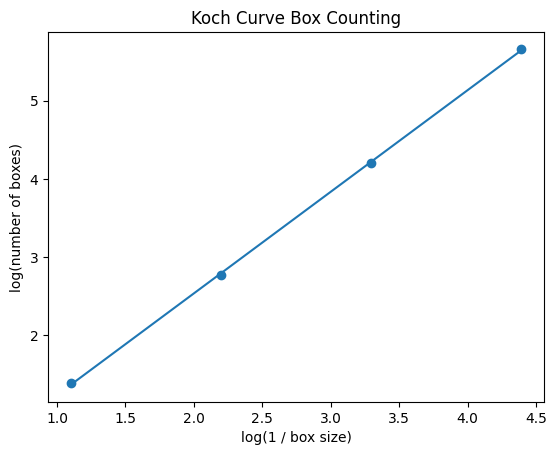

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math


def box_count(points, box_size):

    # Find which box each point belongs to
    boxes = np.floor(points / box_size).astype(int)

    # Count unique boxes
    return len(np.unique(boxes, axis=0))


def fractal_dimension(points):

    # Convert PyTorch tensor to NumPy
    points = points.cpu().numpy()

    # Box sizes to test
    box_sizes = np.array([1/3, 1/9, 1/27, 1/81])

    counts = []

    # Count boxes for each size
    for size in box_sizes:
        counts.append(box_count(points, size))

    counts = np.array(counts)

    # Log values
    x = np.log(1 / box_sizes)
    y = np.log(counts)

    # Find slope of best-fit line
    dimension = np.polyfit(x, y, 1)[0]

    return dimension, x, y

estimated_dimension, x, y = fractal_dimension(points)

theoretical_dimension = math.log(4) / math.log(3)

print("Estimated dimension:", estimated_dimension)
print("Theoretical dimension:", theoretical_dimension)

plt.scatter(x, y)

# Best-fit line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b)

plt.xlabel("log(1 / box size)")
plt.ylabel("log(number of boxes)")
plt.title("Koch Curve Box Counting")

plt.show()

## koch snowflake

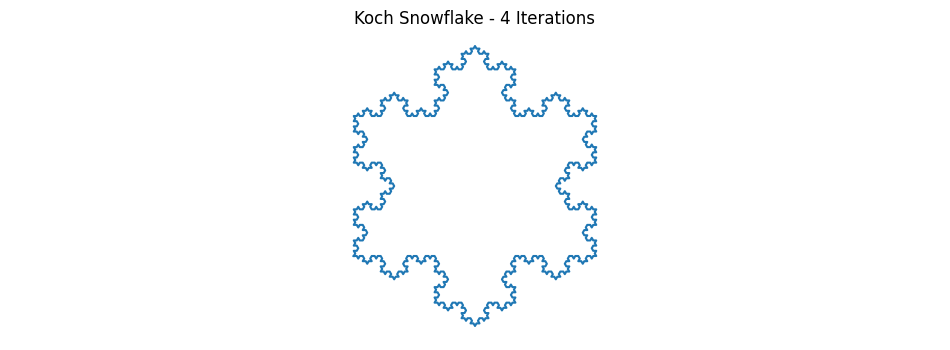

In [17]:
height = math.sqrt(3) / 2

points = torch.tensor([
    [0.0, 0.0],
    [0.5, height],
    [1.0, 0.0],
    [0.0, 0.0]
], device=device)

iterations = 4

for i in range(iterations):
    points = koch_step(points)

# Move to CPU for Matplotlib
points_cpu = points.cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(points_cpu[:, 0], points_cpu[:, 1])

plt.title(f"Koch Snowflake - {iterations} Iterations")
plt.axis("equal")
plt.axis("off")
plt.show()

# AI Usage Reference – Koch Curve

**AI Tool:** ChatGPT
**Project:** Koch Curve implementation and analysis using PyTorch

I used ChatGPT throughout the development of the Koch curve project. Instead of using one prompt to generate the entire project, I used multiple prompts to understand the fractal, create an initial implementation, evaluate the code, improve its parallelism, and perform further analysis.

---

## Prompt 1 – Understanding the Koch Curve

**Prompt:**
“Explain the Koch curve in simple terms and how it is formed.”

**Purpose:**
To understand how the Koch curve works before implementing it.

**Output / Observation:**
AI explained that each line segment is divided into three equal parts and the middle third is replaced by two lines forming a triangular bump. It also explained that the same rule is repeatedly applied to every new segment.

**What I changed:**
No code was changed because this prompt was used to understand the concept.

**What I learned:**
I learned how the Koch curve is formed and that its repeating structure creates self-similarity.

---

## Prompt 2 – Initial Implementation

**Prompt:**
“Implement a Koch curve in Python using PyTorch. Start with a single line segment and apply the standard Koch curve rule recursively/iteratively. For each iteration, go through the existing line segments, divide each segment into thirds, create triangular bump, and store the resulting points. Keep the implementation simple and easy to understand for a beginner, and use Matplotlib to display the result.”

**Purpose:**
To create an initial working implementation of the Koch curve using PyTorch.

**Output / Observation:**
AI generated a working implementation using PyTorch tensors. However, the code contained:

```python
for i in range(len(points) - 1):
```

which processed each line segment individually.

**What I changed:**
I first tested this version as my baseline implementation before investigating whether the PyTorch parallelism could be improved.

**What I learned:**
I learned how `p1`, `p2`, and `p3` are calculated and how rotating the middle third by 60 degrees creates the Koch bump.

---

## Prompt 3 – Reviewing PyTorch Parallelism

**Prompt:**
“Review my current Koch curve implementation. Is PyTorch actually a major part of the fractal-generation algorithm, and is the code making reasonable use of PyTorch parallelism? Explain specifically which parts are sequential and which parts can be processed simultaneously.”

**Purpose:**
To evaluate whether my initial code was using PyTorch and GPU parallelism effectively.

**Output / Observation:**
AI explained that PyTorch was being used for the coordinate calculations, but the loop over individual line segments was sequential. It identified that all segments within the same iteration are independent and could be processed together.

**What I changed:**
I decided to replace the segment-by-segment loop with vectorised tensor operations.

**What I learned:**
The iterations themselves cannot be processed together because each new iteration depends on the result of the previous one. However, all segments inside one iteration can be processed together.

---

## Prompt 4 – Vectorised PyTorch Implementation

**Prompt:**
“Modify the Koch curve implementation so that all line segments in one iteration are processed together using PyTorch tensor operations instead of looping through every segment individually. Keep the code understandable and explain what was changed.”

**Purpose:**
To improve the use of PyTorch parallelism.

**Output / Observation:**
AI removed the inner Python loop and used:

```python
start = points[:-1]
end = points[1:]
```

to represent every segment at once. Calculations for `direction`, `p1`, `p2`, and `p3` were then performed using tensor operations.

**What I changed:**
I used this vectorised implementation as the main version of my Koch curve.

I also manually changed the visualisation so that it displays:

* iteration 4,
* iteration 6,
* a zoomed view of iteration 6.

For the zoomed view, I manually selected:

```python
plt.xlim(0.11, 0.23)
plt.ylim(0.05, 0.17)
```

**What I learned:**
Vectorisation allows PyTorch to operate on many line segments together instead of repeatedly processing each segment through a Python loop.

---

## Prompt 5 – Comparing Iteration 4 and 6

**Prompt:**
“I want to compare Koch curves generated with 4 iterations and 6 iterations. What useful properties should I compare, and what should I expect to observe as the number of iterations increases?”

**Purpose:**
To investigate how increasing the iteration count affects the fractal.

**Output / Observation:**
AI suggested comparing:

* number of segments,
* segment length,
* total curve length,
* visual detail,
* computation and memory requirements.

It showed that iteration 4 has 256 segments while iteration 6 has 4096 segments.

**What I changed:**
I used iterations 4 and 6 for my comparison and added the zoomed iteration 6 visualisation manually.

**What I learned:**
Higher iterations create much smaller details while maintaining the same repeating Koch pattern.

---

## Prompt 8 – Fractal Dimension

**Prompt:**
“Explain the fractal dimension of the Koch curve in simple terms. Show how the theoretical dimension is obtained and suggest a way I can estimate the fractal dimension using my generated curve.”

**Purpose:**
To provide mathematical analysis of the Koch curve.

**Output / Observation:**
AI explained that every segment becomes four smaller segments, each scaled by one-third.

The theoretical fractal dimension is:

$$
D = \frac{\log(4)}{\log(3)}
$$

which is approximately:

$$
D \approx 1.2619
$$

It also suggested box counting as an experimental method.

**What I changed:**
I decided to implement box counting so I could compare an estimated dimension with the theoretical value.

**What I learned:**
The Koch curve has a dimension between 1 and 2 because it is more complex than a normal line but does not fill a complete two-dimensional area.

---

## Prompt 9 – Implementing Box Counting

**Prompt:**
“how can i implement box counting to get fractal dimension from my generated fractal and compare with the theoritical dimension”

**Purpose:**
To estimate the fractal dimension computationally.

**Output / Observation:**
AI explained that I could use several grid box sizes, count the number of boxes occupied by the curve, and compare:

$$
\log(N)
$$

against:

$$
\log(1/\epsilon)
$$

The slope of the resulting relationship gives an estimate of the fractal dimension.

**What I changed:**
I implemented the box-counting approach and used it to compare the estimated fractal dimension with the theoretical value.

**What I learned:**
Box counting estimates dimension by measuring how quickly the number of required boxes increases as the box size becomes smaller.

---

## Prompt 11 – Koch Snowflake Extension

**Prompt:**
“what should i modify to turn this into koch snowflake”

**Purpose:**
To extend the Koch curve implementation into another related fractal.

**Output / Observation:**
AI suggested replacing the original single line with an equilateral triangle while continuing to use the same `koch_step()` transformation.

**What I changed:**
I tested different orders for the triangle vertices. I found that the order of the points affected whether the 60-degree Koch bumps pointed inward or outward.

I adjusted either the point ordering or the sign of the rotation angle so that the bumps pointed outside the triangle.

**What I learned:**
The Koch curve and Koch snowflake use the same transformation rule. The main difference is that the normal Koch curve begins with one line, while the snowflake begins with three connected sides forming an equilateral triangle.

I also learned that clockwise and counter-clockwise point ordering affects which direction a positive 60-degree rotation points.

---

# Overall Reflection

AI was used throughout the project as a learning and development tool rather than to produce the whole project from one prompt.

My process was:

**Understand the Koch curve → generate a basic version → inspect its parallelism → vectorise the algorithm → compare iterations → study fractal dimension → implement box counting → extend the implementation to a Koch snowflake.**

I also made manual decisions and modifications, including selecting iterations 4 and 6, creating the zoomed iteration 6 visualisation using manually selected `xlim` and `ylim` values, and investigating the correct orientation for the Koch snowflake.
